In [ ]:
import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model("eurosat_efficientnetv2b0.keras")
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,113,680 (50.02 MB)

 Trainable params: 3,429,370 (13.08 MB)

 Non-trainable params: 2,825,568 (10.78 MB)

 Optimizer params: 6,858,742 (26.16 MB)

In [ ]:
base_model = model.get_layer("efficientnetv2-b0")
base_model.summary()

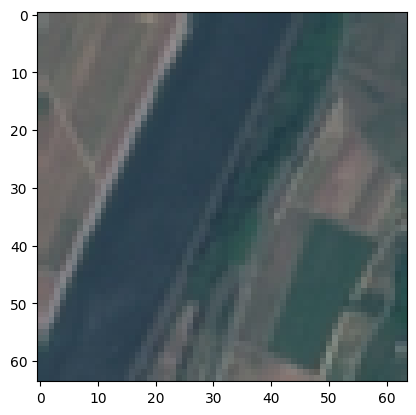

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2

img_path = "img6.jpg"
image = Image.open(img_path)
image = image.convert("RGB")
plt.imshow(image)

In [ ]:
def preprocess_image(img):
    image = img.resize((224, 224))
    image_array = np.array(image)
    image_array = np.expand_dims(image_array, axis=0) #expand dim from (224,224,3) to (1,224,224,3), since model expects a batch image for one image
    return image_array

img_input = preprocess_image(image)
print(img_input.shape)

(1, 224, 224, 3)


In [ ]:
CLASS_NAMES = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
               'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

preds = model.predict(img_input)[0]
pred_idx = np.argmax(preds)
pred_class = CLASS_NAMES[pred_idx]
confidence = preds[pred_idx]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [ ]:
print("Predicted class:", CLASS_NAMES[pred_idx])
print("Confidence:", confidence)

Predicted class: River
Confidence: 0.99999976


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
  # Create a new model that takes an image input and outputs the last convolution layer ouput and final predictions
  grad_model = tf.keras.models.Model(
      model.inputs,
      [
          model.get_layer("efficientnetv2-b0").get_layer(last_conv_layer_name).output,
          model.output
      ]
  )

  # record gradients -> GradientTape keeps track of gradients inside the block
  with tf.GradientTape() as tape:
    # forward pass
    conv_outputs, predictions = grad_model(img_array, training=False)

    # pick the predicted class
    if pred_index is None:
      pred_index = tf.argmax(predictions[0])

    # Compute confidence by selecting class column and keep batch dimension
    class_score = predictions[:, pred_index]


  # Compute gradients
  grads = tape.gradient(class_score, conv_outputs)

  # Average gradients spatially over height, width and batch
  pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

  # weight the feature maps
  conv_outputs = conv_outputs[0]
  # "@" performs matrix multiplication; "..." keeps existing dimensions;
  # "tf.newaxis" adds a new dimension to make pooled_grads (C,) -> (C,1)
  heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

  # remove extra dimensions
  heatmap = tf.squeeze(heatmap)

  # normalize heatmap by removing maximum values and scaling between 0 and 1
  heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

  return heatmap.numpy()

In [ ]:
last_conv_layer = "top_conv"
base_model_name = "efficientnetv2-b0"

def get_gradcam_heatmap(img_array, model, base_model_name, last_conv_layer_name, pred_index):
    # 1. Access the nested base model
    base_model = model.get_layer(base_model_name)

    # 2. Create a sub-model that outputs both the target conv layer and the base model's output
    base_grad_model = tf.keras.models.Model(
        base_model.inputs,
        [
            base_model.get_layer(last_conv_layer_name).output,
            base_model.output
         ]
    )

    # 3. Identify the classifier layers (everything after the base model)
    top_layers = []
    found_base = False
    for layer in model.layers:
        if layer.name == base_model_name:
            found_base = True
            continue
        if found_base:
            top_layers.append(layer)

    # 4. Record gradients -> GradientTape keeps track of gradients inside the block
    with tf.GradientTape() as tape:
        # Forward pass through the base part
        conv_outputs, base_output = base_grad_model(img_array)

        # Forward pass through the top part (the classifier)
        x = base_output
        for layer in top_layers:
            x = layer(x)
        predictions = x

        # Select the score for the target class
        class_channel = predictions[:, pred_index]

    # 5. Compute gradients of the predicted class with respect to the feature map
    grads = tape.gradient(class_channel, conv_outputs)

    # 6. Average gradients spatially over height, width and batch
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 7. Weight the feature maps and create heatmap
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    # "@" performs matrix multiplication; "..." keeps existing dimensions;
    # "tf.newaxis" adds a new dimension to make pooled_grads (C,) -> (C,1)

    # 8. Remove extra dimensions
    heatmap = tf.squeeze(heatmap)

    # 7. Apply ReLU and normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

# Execute the generation using the existing prediction index
img_input_tensor = tf.cast(img_input, tf.float32)
heatmap = get_gradcam_heatmap(img_input_tensor, model, base_model_name, last_conv_layer, pred_idx)

print("Heatmap generated successfully.")
print("Heatmap shape:", heatmap.shape)

Heatmap generated successfully.
Heatmap shape: (7, 7)


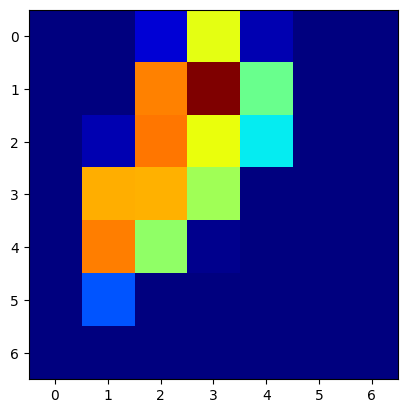

In [ ]:
plt.imshow(heatmap, cmap="jet")

In [ ]:
def overlay_heatmap(heatmap, image, alpha=0.4):
    # Resize heatmap to match image size
    heatmap = cv2.resize(heatmap, image.size)

    # Convert heatmap from [0,1] to [0,255]
    heatmap = np.uint8(255 * heatmap)

    # Turn grayscale heatmap into color
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Convert PIL image into numpy array
    image = np.array(image)

    # Convert RGB to BGR
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    # Overlay heatmap on image
    superimposed_img = heatmap * alpha + image

    # Convert result to uint8
    superimposed_img = np.uint8(superimposed_img)

    # Comvert BGR to RGB for display
    return cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)


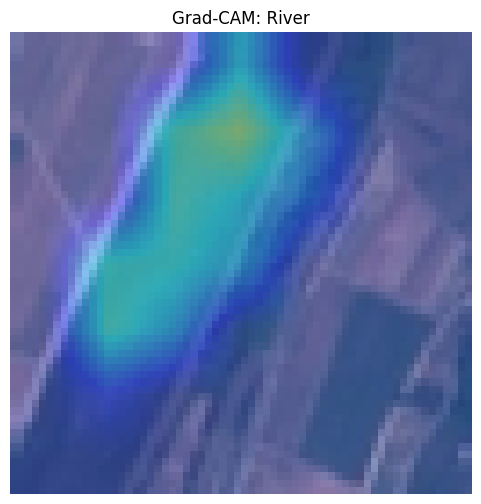

In [ ]:
cam_image = overlay_heatmap(heatmap, image)

plt.figure(figsize=(6, 6))
plt.imshow(cam_image)
plt.title(f"Grad-CAM: {CLASS_NAMES[pred_idx]}")
plt.axis("off")
plt.show()